In [1]:
!pip install pandas

In [15]:

 # task 0 part 1
import pandas as pd

# 1. Load the raw dictionary
raw_dict = pd.read_pickle("delta_a100_gpu_xid_dataset.pkl")

# 3. Flatten the dictionary into a single list of all errors
all_errors = []
for date, error_list in raw_dict.items():
   for i in error_list:
      i["Date"] = date
      all_errors.append(i)

# 4. Convert that list into a Pandas DataFrame
print(df.columns)
df = pd.DataFrame(all_errors)
df = df[["Date", "datetime", "timestamp", "node_name", "device_id","XID","Tag"]]
df.sort_values(by = 'timestamp')

df.head(6)


Index(['Date', 'datetime', 'timestamp', 'node_name', 'device_id', 'XID'], dtype='str')


,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


In [16]:

march_10_2024_errors = df[df['datetime'].astype(str).str.startswith('2024-03-10')]

march_10_2024_errors.head(9) # see the first few rows in pandas



,Date,datetime,timestamp,node_name,device_id,XID,Tag
49368,2024-03-10,2024-03-10T00:07:03.882015-05:00,1.710047e+09,gpua014,0000:07:00,43,043_GPU_STOPPED_PROCESSING
49369,2024-03-10,2024-03-10T00:08:19.391145-05:00,1.710047e+09,gpua072,0000:85:00,43,043_GPU_STOPPED_PROCESSING
49370,2024-03-10,2024-03-10T00:11:39.689608-05:00,1.710047e+09,gpua010,0000:46:00,43,043_GPU_STOPPED_PROCESSING
49371,2024-03-10,2024-03-10T00:28:36.850641-05:00,1.710049e+09,gpua001,0000:46:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
49372,2024-03-10,2024-03-10T00:41:02.058856-05:00,1.710049e+09,gpua083,0000:46:00,119,119_GSP_RPC_timeout
49373,2024-03-10,2024-03-10T00:49:47.742834-05:00,1.710050e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
49374,2024-03-10,2024-03-10T00:55:44.740825-05:00,1.710050e+09,gpua017,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
49375,2024-03-10,2024-03-10T01:04:59.972015-05:00,1.710051e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
49376,2024-03-10,2024-03-10T01:26:45.244245-05:00,1.710052e+09,gpua001,0000:07:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


In [40]:
#task 0 part 2 and 3 
count_XID = set(march_10_2024_errors['XID']) # existance hash set to see unique XID's
print('the number of unique XIDs:', len(count_XID)) # its 6 
print('here is all the unique ones')
for i in count_XID:
    print(i)

# convert back to list for task 0 pt 2.2
Uniq_XID = list(count_XID)
print(Uniq_XID) 

the number of unique XIDs: 6
here is all the unique ones
74
43
45
13
119
31
[74, 43, 45, 13, 119, 31]


In [41]:
!pip install matplotlib

In [27]:
# Task 1 part 1 print the first 10 rows (already in increasing order by timestamp)


unix_time = df.at[0, "timestamp"]
human_readable = pd.to_datetime(unix_time, unit='s')
print("first time stamp in Unix is ", unix_time)
print("first time stamp in human readeable format is ", human_readable)
df.head(11) 





first time stamp in Unix is  1658071647.4228365
first time stamp in Unix is  2022-07-17 15:27:27.422836542


,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


In [59]:
# Prob XID 43 = Number of times XID is 43 / Total Amount of Rows of Data
# task 1 part 2 a
count_XID_43 = df[df['XID'] == 43] 
#number of errors with XID = 43

print('errors with XID equals 43:' , len(count_XID_43))

#total rows
total = len(df)
print('all rows total:' , total)

Probability_Task1_Part2a = len(count_XID_43)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2)

errors with XID equals 43: 8592
all rows total: 73514
probability that XID = 43 when random sample: 0.11687569714612182


In [61]:
#task 1 part 2 b
count_XID_119 = df[df['XID'] == 119] 
#number of errors with XID = 119

print('errors with XID equals 119:' , len(count_XID_119))

#total rows
print('all rows total:' , total)

Probability_Task1_Part2b = len(count_XID_119)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2b)

errors with XID equals 43: 1303
all rows total: 73514
probability that XID = 43 when random sample: 0.017724515058356233


In [ ]:
# task 1 part 2 c
# user error is way more likely than hardware error 0.116>0.0177

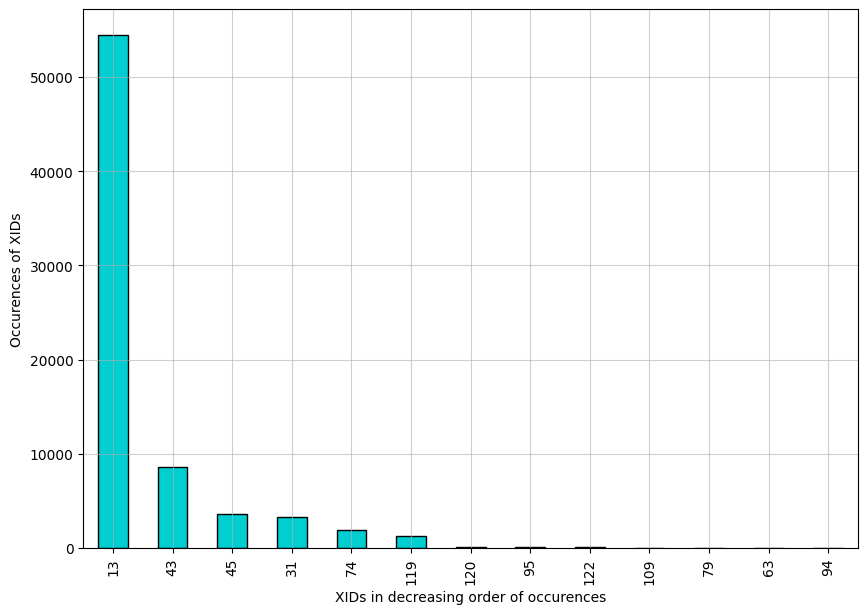

In [28]:
import matplotlib.pyplot as plt
plot_errorXIDs = df['XID'].value_counts()
plt.figure(figsize=(10,7))
# yoo dark turquoise is the color for sure
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 

plt.xlabel('XIDs in decreasing order of occurences')
plt.ylabel('Occurences of XIDs')

plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()


In [32]:
# Based on the plot the most dominant XID is 13. 
# Top 5 XIDs that occurred in the dataset are 13, 43, 45, 31 and 74
# According to the study XID 74 is an interconnect error, Description according to study: NVLink error indicating connection issues between GPUs via NVLink interconnection.

# Finding its Tag now

tag_74 = df.loc[df['XID'] == 74, 'Tag'].unique()[0]
print("tag for XID 74 is ", tag_74)



tag for XID 74 is  074_NVLINK_error


In [41]:
# making histogram of timestamps using .diff

time_intervals = df["timestamp"].diff()
print(time_intervals)


0                NaN
1         121.881796
2        2021.788913
3          64.714361
4         398.010359
            ...     
73509    2046.415668
73510     331.060869
73511     716.815888
73512     329.312100
73513     834.598951
Name: timestamp, Length: 73514, dtype: float64


the mean interarrival time is 1054.4875208708004
the standard deviation is 1061.687541810317


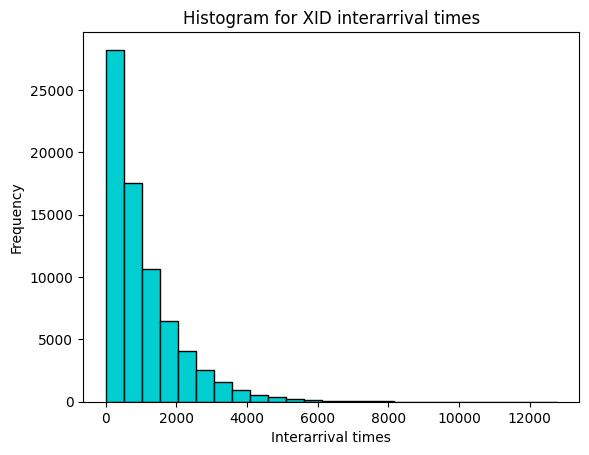

In [58]:
#plotting histogram
plt.hist(time_intervals, bins = 25, color = 'darkturquoise',edgecolor  = 'black')
plt.title("Histogram for XID interarrival times")
plt.ylabel("Frequency")
plt.xlabel("Interarrival times")


mean_time = time_intervals.mean()
print("the mean interarrival time is", mean_time)
time_interval_std = time_intervals.std()
print("the standard deviation is", time_interval_std)

In [ ]:
# since the entire system is being used and every XID is critical the average time a user would be able to run their job before being interrupted by an XID is the same as the MEAN = 1054.49 seconds